# 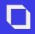 IONCOR Oy Scrap Value Forecasting Dashboard (Random Forest Regressor,XGBoost, ARIMA, LSTM, Prophet)

## 📦 Import, Load libraries and packages

In [3]:
import pandas as pd
import numpy as np
import panel as pn
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from prophet import Prophet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error 
import warnings
warnings.filterwarnings("ignore")
pn.extension()

2026-04-16 21:52:40.752837: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
!pip install pandas numpy matplotlib scikit-learn xgboost statsmodels tensorflow prophet

## 📁 Uploaded Files and Setup

In [6]:
file_dict = {
     "Cell_1_y7": "Cell_1_y7.XLSX",
    "BDU_Y7": "BDU_Y7.XLSX",
    "BMS_48": "BMS_48.XLSX",
    "Converter_48": "Converter_48.XLSX",
    "Base_Tray_vent_Y7": "Base_Tray_vent_Y7.XLSX",
    "BMU_Y7": "BMU_Y7.XLSX",
    "Cell_48": "Cell_48.XLSX",
    "Cooler_48": "Cooler_48.XLSX",
     "Busbar1_Y7": "Busbar1_Y7.XLSX",
    "Cover_Y7": "Cover_Y7.XLSX",
    "Cell_3_y7": "Cell_3_y7.XLSX",
    "Circuit_board_Sensor_48": "Circuit_board_Sensor_48.XLSX",
     "ZELLBLOCK_RE_Uki": "ZELLBLOCK_RE_Uki.XLSX",
    "ZELLBLOCK_LI_Uki": "ZELLBLOCK_LI_Uki.XLSX",
    "LI_ION_Cell_Uki": "LI_ION_Cell_Uki.XLSX",
    "Prismatic_Cell_Uki": "Prismatic_Cell_Uki.XLSX"
    
}


## ⚙️ Define Files and Preprocessing Function

In [8]:
def preprocess_time_series(file_path):
    # Detect if file is CSV or Excel
    if file_path.endswith('.csv'):
        df = pd.read_csv(file_path)
    else:
        df = pd.read_excel(file_path)
        
    df = df[["Posting Date", "Unit Price"]]
    df['Posting Date'] = pd.to_datetime(df['Posting Date'])
    df = df.groupby("Posting Date")["Unit Price"].sum().reset_index()
    df = df.sort_values("Posting Date")
    df.dropna(inplace=True)
    return df

## 🧠 XGBoost Prediction

In [10]:
def xgboost_forecast(df):
    # 1. Ensure 'Posting Date' is in datetime format
    df['Posting Date'] = pd.to_datetime(df['Posting Date'])
    
    # 2. Define the reference date (January 1, 2019)
    reference_date = pd.Timestamp('2019-01-01')
    
    # 3. Calculate the number of days passed
    df['Days_Since_2019'] = (df['Posting Date'] - reference_date).dt.days
    
    # 4. Set your input X and target y
    X = df[['Days_Since_2019']]
    y = df['Unit Price']

    # --- Model Training ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor(n_estimators=200, learning_rate=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # --- Metrics ---
    rmse = root_mean_squared_error(y_test, y_pred)
    # Calculate MAPE and multiply by 100 for percentage
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 
    
    return y_test.reset_index(drop=True), y_pred, rmse, mape

## 🔁 Random Forest Forecasting

In [12]:
def random_forest_forecast(df):
    # Feature Engineering
    df['Year'] = df['Posting Date'].dt.year
    df['Month'] = df['Posting Date'].dt.month
    df['Day'] = df['Posting Date'].dt.day
    df['DayOfWeek'] = df['Posting Date'].dt.dayofweek
    df['DayOfYear'] = df['Posting Date'].dt.dayofyear
    
    # Selecting Features and Target
    X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear']]
    y = df['Unit Price']
    
    # Train/Test Split (Time-series sensitive)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Model Training
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics calculation
    # root_mean_squared_error is the new preferred way in sklearn
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    # Returning actuals, predictions, and both metrics
    return y_test.reset_index(drop=True), y_pred, rmse, mape

## 🔁 ARIMA Forecasting

In [14]:
def arima_forecast(df):
    series = df.set_index('Posting Date')['Unit Price']
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=int(len(series)*0.2))
    y_true = series[-len(forecast):]
    
    # --- Metrics ---
    rmse = mean_squared_error(y_true, forecast, squared=False)
    mape = mean_absolute_percentage_error(y_true, forecast) * 100
    
    return y_true, forecast, rmse, mape

## 🔮 Prophet Forecasting

In [16]:
def prophet_forecast(df):
    # 1. Prepare Data
    df_prophet = df.rename(columns={'Posting Date': 'ds', 'Unit Price': 'y'})
    
    # 2. Split Data
    train_size = int(len(df_prophet) * 0.8)
    train, test = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]
    
    # 3. Model Training
    model = Prophet()
    model.fit(train)
    
    # 4. Forecasting
    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)
    
    # 5. Extract Results
    y_pred = forecast['yhat'].iloc[train_size:].values
    y_true = test['y'].values  # Using .values for easier math
    
    # 6. Metrics Calculation
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    
    # Calculate MAPE: mean(|(actual - pred) / actual|) * 100
    # Added a filter to avoid division by zero if an actual value is 0
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    
    return y_true, y_pred, rmse, mape


## 🤖 LSTM Forecasting

### Prepare data

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

def lstm_forecast(df):
    # 1. Prepare the data
    data = df['Unit Price'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)
    
    # 2. Create dataset function
    def create_dataset(dataset, look_back=1):
        X, Y = [], []
        for i in range(len(dataset)-look_back-1):
            a = dataset[i:(i+look_back), 0]
            X.append(a)
            Y.append(dataset[i + look_back, 0])
        return np.array(X), np.array(Y)
    
    # 3. Create sequences
    look_back = 3
    X, y = create_dataset(data_scaled, look_back)
    
    # 4. Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # 5. Reshape for LSTM [samples, time steps, features]
    X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
    X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
    
    # 6. Build and train model
    model = Sequential()
    model.add(LSTM(50, input_shape=(1, look_back)))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=0)
    
    # 7. Make predictions
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # 8. Calculate Metrics
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    
    # Adding MAPE (Mean Absolute Percentage Error)
    # Note: We multiply by 100 to get the percentage value
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return y_true.flatten(), y_pred.flatten(), rmse, mape

# 📈 Unit Price Analysis

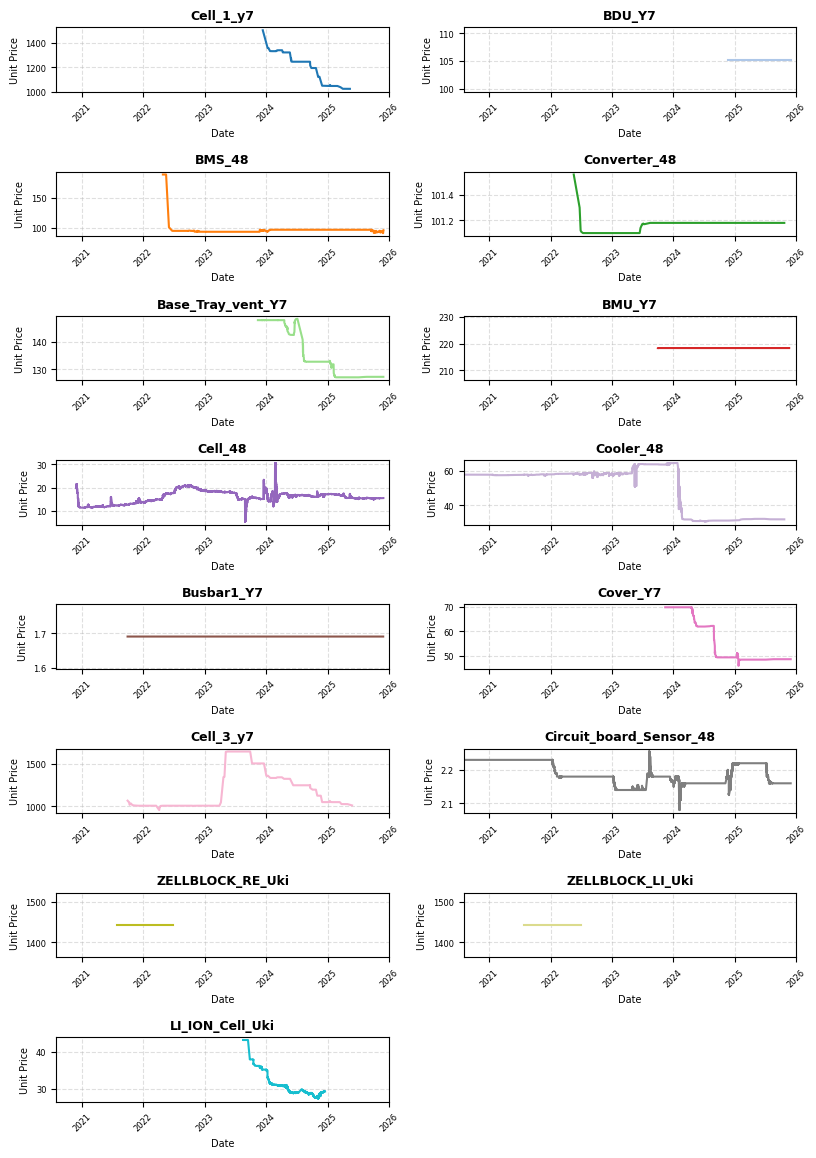

In [21]:
def plot_unit_prices():
    # A4 page dimensions: 8.27 x 11.69 inches (vertical)
    fig, axes = plt.subplots(8, 2, figsize=(8.27, 11.69))
    axes = axes.flatten()
    
    # Generate distinct colors for each product
    colors = cm.tab20(np.linspace(0, 1, len(file_dict)))
    
    # Define the common timeline (2019-2026)
    timeline_start = pd.Timestamp('2020-08-01')
    timeline_end = pd.Timestamp('2026-01-01')
    
    product_list = list(file_dict.items())
    
    # Iterate through each product and plot in the grid
    for idx, (product_name, file_path) in enumerate(product_list):
        try:
            # Load the Excel file
            df = pd.read_excel(file_path)
            
            # Ensure 'Posting Date' is in datetime format
            df['Posting Date'] = pd.to_datetime(df['Posting Date'])
            
            # Sort by date
            df = df.sort_values('Posting Date')
            
            # Compute Unit Price
            df['Unit Price'] = df['Amount in LC'] / df['Quantity']
            
            # Plot on the corresponding subplot
            ax = axes[idx]
            ax.plot(df['Posting Date'], df['Unit Price'], 
                   color=colors[idx], linewidth=1.5)
            ax.set_title(product_name, fontsize=9, fontweight='bold')
            ax.set_xlabel('Date', fontsize=7)
            ax.set_ylabel('Unit Price', fontsize=7)
            ax.tick_params(axis='both', labelsize=6)
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.xaxis.set_major_locator(mdates.YearLocator(1))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.tick_params(axis='x', rotation=45)
            
            # Set common timeline for all subplots
            ax.set_xlim(timeline_start, timeline_end)
            
        except Exception as e:
            ax = axes[idx]
            ax.text(0.5, 0.5, f"Error loading\n{product_name}", 
                   ha='center', va='center', fontsize=8)
            ax.set_title(product_name, fontsize=9, fontweight='bold')
            ax.set_xlim(timeline_start, timeline_end)
    
    # Hide the last empty subplot (17 products + 1 empty = 18 total)
    axes[-1].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('Unit_Prices_Grid.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Run the plotting function
plot_unit_prices()

## 📊 Plotting function

In [23]:
def update_dashboard(event):
    # Get selected values from widgets
    component = component_selector.value
    model = model_selector.value
    
    # Load and preprocess data
    df = preprocess_time_series(file_dict[component])
    
    metrics = []
    plots = []

    # Run Selected models
    if model in ['All Models', 'XGBoost']:
        y_true_xgb, y_pred_xgb, rmse_xgb = xgboost_forecast(df)
        
        # Calculate MAPE
        mape_xgb = mean_absolute_percentage_error(y_true_xgb, y_pred_xgb)
        
        metrics.append(f"**XGBoost**\nRMSE: {rmse_xgb:.2f}\nMAPE: {mape_xgb:.2%}")
        plots.append(('XGBoost', create_plot(y_true_xgb, y_pred_xgb, 'XGBoost')))
    
    if model in ['All Models', 'Random Forest']:
        y_true_rf, y_pred_rf, rmse_rf = random_forest_forecast(df)
        
        # Calculate MAPE
        mape_rf = mean_absolute_percentage_error(y_true_rf, y_pred_rf)
        
        metrics.append(f"**Random Forest**\nRMSE: {rmse_rf:.2f}\nMAPE: {mape_rf:.2%}")
        plots.append(('Random Forest', create_plot(y_true_rf, y_pred_rf, 'Random Forest')))
    
    if model in ['All Models', 'ARIMA']:
        y_true_arima, y_pred_arima, rmse_arima = arima_forecast(df)
        
        # Calculate MAPE
        mape_arima = mean_absolute_percentage_error(y_true_arima, y_pred_arima)
        
        metrics.append(f"**ARIMA**\nRMSE: {rmse_arima:.2f}\nMAPE: {mape_arima:.2%}")
        plots.append(('ARIMA', create_plot(y_true_arima, y_pred_arima, 'ARIMA')))

    if model in ['All Models', 'Prophet']:
        y_true_prophet, y_pred_prophet, rmse_prophet = prophet_forecast(df)
        
        # Calculate MAPE
        mape_prophet = mean_absolute_percentage_error(y_true_prophet, y_pred_prophet)
        
        metrics.append(f"**Prophet**\nRMSE: {rmse_prophet:.2f}\nMAPE: {mape_prophet:.2%}")
        plots.append(('Prophet', create_plot(y_true_prophet, y_pred_prophet, 'Prophet')))
    
    if model in ['All Models', 'LSTM']:
        y_true_lstm, y_pred_lstm, rmse_lstm = lstm_forecast(df)
        
        # Calculate MAPE
        mape_lstm = mean_absolute_percentage_error(y_true_lstm, y_pred_lstm)
        
        metrics.append(f"**LSTM**\nRMSE: {rmse_lstm:.2f}\nMAPE: {mape_lstm:.2%}")
        plots.append(('LSTM', create_plot(y_true_lstm, y_pred_lstm, 'LSTM')))

    # Update metrics and plots
    # Added separator '---' to make distinct models easier to read
    metrics_pane.object = "\n\n---\n\n".join(metrics)
    
    if model == 'All Models':
        # Create a grid of all plots
        grid = pn.GridBox(
            *[plot[1] for plot in plots],
            ncols=2, nrows=3, sizing_mode='stretch_width'
        )
        return pn.Column(metrics_pane, grid)
    else:
        for name, plot in plots:
            if name == model:
                return pn.Column(metrics_pane, plot)

In [24]:
def create_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(10,5))
    plt.plot(y_true.values if hasattr(y_true, 'values') else y_true, label='Actual')
    plt.plot(y_pred, label='Forecast')
    plt.title(f'{model_name} Forecast')
    plt.xlabel("Time")
    plt.ylabel("Scrap Value")
    plt.legend()
    return pn.pane.Matplotlib(plt.gcf(), tight=True)

## 📉 Dashboard components

In [26]:
def update_dashboard(event):
    # Get selected values from widgets
    component = component_selector.value
    model_choice = model_selector.value # Renamed to avoid conflict with 'model' objects
    
    # Load and preprocess data
    df = preprocess_time_series(file_dict[component])
    
    metrics = []
    plots = []
    mape_scores = {} 

    # --- Run Selected Models ---
    # Note: Each function now returns: y_true, y_pred, rmse, mape
    
    if model_choice in ['All Models', 'XGBoost']:
        y_true, y_pred, rmse, mape = xgboost_forecast(df)
        metrics.append(f"**XGBoost**\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")
        plots.append(('XGBoost', create_plot(y_true, y_pred, 'XGBoost')))
        mape_scores['XGBoost'] = mape / 100 # Convert to decimal for the plot logic
    
    if model_choice in ['All Models', 'Random Forest']:
        y_true, y_pred, rmse, mape = random_forest_forecast(df)
        metrics.append(f"**Random Forest**\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")
        plots.append(('Random Forest', create_plot(y_true, y_pred, 'Random Forest')))
        mape_scores['Random Forest'] = mape / 100
    
    if model_choice in ['All Models', 'ARIMA']:
        y_true, y_pred, rmse, mape = arima_forecast(df)
        metrics.append(f"**ARIMA**\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")
        plots.append(('ARIMA', create_plot(y_true, y_pred, 'ARIMA')))
        mape_scores['ARIMA'] = mape / 100

    if model_choice in ['All Models', 'Prophet']:
        y_true, y_pred, rmse, mape = prophet_forecast(df)
        metrics.append(f"**Prophet**\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")
        plots.append(('Prophet', create_plot(y_true, y_pred, 'Prophet')))
        mape_scores['Prophet'] = mape / 100
    
    if model_choice in ['All Models', 'LSTM']:
        y_true, y_pred, rmse, mape = lstm_forecast(df)
        metrics.append(f"**LSTM**\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")
        plots.append(('LSTM', create_plot(y_true, y_pred, 'LSTM')))
        mape_scores['LSTM'] = mape / 100

    # Update metrics text pane
    metrics_pane.object = "\n\n---\n\n".join(metrics)
    
    # --- Layout Logic ---
    
    if model_choice == 'All Models':
        # 1. Create the Comparison Bar Chart
        fig_comp, ax_comp = plt.subplots(figsize=(10, 4))
        names = list(mape_scores.keys())
        values = list(mape_scores.values())
        
        # Plot bars
        bars = ax_comp.bar(names, values, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974'])
        
        # Styling
        ax_comp.set_title('MAPE Comparison (Lower is Better)')
        ax_comp.set_ylabel('MAPE')
        
        # Add text labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax_comp.annotate(f'{height:.1%}',
                             xy=(bar.get_x() + bar.get_width() / 2, height),
                             xytext=(0, 3),  
                             textcoords="offset points",
                             ha='center', va='bottom')
            
        comparison_pane = pn.pane.Matplotlib(fig_comp, tight=True)
        
        # 2. Create Grid for Individual Forecast Plots
        grid = pn.GridBox(
            *[p[1] for p in plots],
            ncols=2, sizing_mode='stretch_width'
        )
        
        return pn.Column(metrics_pane, comparison_pane, grid)
        
    else:
        # Single model view
        selected_plot = None
        for name, plot in plots:
            if name == model_choice:
                selected_plot = plot
                break
        return pn.Column(metrics_pane, selected_plot)

In [27]:
component_selector = pn.widgets.Select(name='Select Component', options=list(file_dict.keys()))
forecast_button = pn.widgets.Button(name='Run Forecasts', button_type='primary')
model_selector = pn.widgets.Select(name='Select Model', 
                                  options=['All Models', 'XGBoost', 'Random Forest', 'ARIMA', 'Prophet', 'LSTM'])

## 📉 Create panes for plots and metrics

In [29]:
xgb_plot_pane = pn.pane.Matplotlib()
rf_plot_pane = pn.pane.Matplotlib()
arima_plot_pane = pn.pane.Matplotlib()
prophet_plot_pane = pn.pane.Matplotlib()
lstm_plot_pane = pn.pane.Matplotlib()
metrics_pane = pn.pane.Markdown()

## 🔁 Update function

In [31]:
import plotly.graph_objects as go

def plot_fixed_forecast(forecast, history):
    """
    forecast: The dataframe containing your predictions (e.g., 'ds', 'yhat', 'yhat_lower', 'yhat_upper')
    history: The original dataframe with 'ds' and 'y'
    """
    fig = go.Figure()

    # 1. Plot Historical Data
    fig.add_trace(go.Scatter(x=history['ds'], y=history['y'], 
                             mode='lines', name='Actual Value',
                             line=dict(color='#1f77b4')))

    # 2. Plot Forecast Data
    fig.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], 
                             mode='lines', name='Forecast',
                             line=dict(color='#ff7f0e', dash='dot')))

    # 3. Add Confidence Interval (Shaded Area)
    fig.add_trace(go.Scatter(
        x=forecast['ds'].tolist() + forecast['ds'].tolist()[::-1],
        y=forecast['yhat_upper'].tolist() + forecast['yhat_lower'].tolist()[::-1],
        fill='toself',
        fillcolor='rgba(255,127,14,0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=False,
        name='Confidence Interval'
    ))

    # Formatting the Dashboard
    fig.update_layout(
        title='<b>Ioncor Scrap Value: Forecast vs Actual</b>',
        xaxis_title='Date',
        yaxis_title='Price (Value)',
        template='plotly_white',
        hovermode="x unified"
    )
    
    fig.show()


# 📊 Model Evaluation Summary

In [33]:
from IPython.display import display

def generate_metrics_summary():
    results_rmse = []
    results_mape = []
    
    print("Calculating metrics for all components (this may take a moment)...")
    
    for component_name, file_name in file_dict.items():
        try:
            # 1. Preprocess the data using your existing function
            df = preprocess_time_series(file_name)
            
            # 2. Run XGBoost
            # Note: We use _ to ignore the prediction arrays, keeping only metrics
            _, _, rmse_xgb, mape_xgb = xgboost_forecast(df)
            
            # 3. Run ARIMA
            _, _, rmse_arima, mape_arima = arima_forecast(df)
            
            # 4. Store RMSE results
            results_rmse.append({
                'Component': component_name,
                'XGBoost RMSE': round(rmse_xgb, 2),
                'ARIMA RMSE': round(rmse_arima, 2),
                'Best Model': 'XGBoost' if rmse_xgb < rmse_arima else 'ARIMA'
            })
            
            # 5. Store MAPE results
            results_mape.append({
                'Component': component_name,
                'XGBoost MAPE (%)': round(mape_xgb, 2),
                'ARIMA MAPE (%)': round(mape_arima, 2),
                'Best Model': 'XGBoost' if mape_xgb < mape_arima else 'ARIMA'
            })
            
        except Exception as e:
            print(f"Could not calculate for {component_name}: {e}")

    # Convert to DataFrames
    df_rmse = pd.DataFrame(results_rmse)
    df_mape = pd.DataFrame(results_mape)
    
    return df_rmse, df_mape

# Generate and display the tables
df_rmse_results, df_mape_results = generate_metrics_summary()

print("\nTable 1: RMSE Results (Lower is better)")
display(df_rmse_results)

print("\nTable 2: MAPE Results (Lower is better)")
display(df_mape_results)
# 📊 Model Evaluation Summary
from IPython.display import display

def generate_metrics_summary():
    results_rmse = []
    results_mape = []
    
    print("Calculating metrics for all components (this may take a moment)...")
    
    for component_name, file_name in file_dict.items():
        try:
            # 1. Preprocess the data using your existing function
            df = preprocess_time_series(file_name)
            
            # 2. Run XGBoost
            # Note: We use _ to ignore the prediction arrays, keeping only metrics
            _, _, rmse_xgb, mape_xgb = xgboost_forecast(df)
            
            # 3. Run ARIMA
            _, _, rmse_arima, mape_arima = arima_forecast(df)
            
            # 4. Store RMSE results
            results_rmse.append({
                'Component': component_name,
                'XGBoost RMSE': round(rmse_xgb, 2),
                'ARIMA RMSE': round(rmse_arima, 2),
                'Best Model': 'XGBoost' if rmse_xgb < rmse_arima else 'ARIMA'
            })
            
            # 5. Store MAPE results
            results_mape.append({
                'Component': component_name,
                'XGBoost MAPE (%)': round(mape_xgb, 2),
                'ARIMA MAPE (%)': round(mape_arima, 2),
                'Best Model': 'XGBoost' if mape_xgb < mape_arima else 'ARIMA'
            })
            
        except Exception as e:
            print(f"Could not calculate for {component_name}: {e}")

    # Convert to DataFrames
    df_rmse = pd.DataFrame(results_rmse)
    df_mape = pd.DataFrame(results_mape)
    
    return df_rmse, df_mape

# Generate and display the tables
df_rmse_results, df_mape_results = generate_metrics_summary()

print("\nTable 1: RMSE Results (Lower is better)")
display(df_rmse_results)

print("\nTable 2: MAPE Results (Lower is better)")
display(df_mape_results)

Calculating metrics for all components (this may take a moment)...

Table 1: RMSE Results (Lower is better)


,Component,XGBoost RMSE,ARIMA RMSE,Best Model
0,Cell_1_y7,501.20,479.44,ARIMA
1,BDU_Y7,118.68,99.12,ARIMA
2,BMS_48,852.00,857.92,XGBoost
3,Converter_48,59.60,54.71,ARIMA
4,Base_Tray_vent_Y7,104.14,105.63,XGBoost
5,BMU_Y7,322.88,213.40,ARIMA
6,Cell_48,586.49,584.70,ARIMA
7,Cooler_48,106.84,92.55,ARIMA
8,Busbar1_Y7,2.48,2.38,ARIMA
9,Cover_Y7,53.63,57.26,XGBoost



Table 2: MAPE Results (Lower is better)


,Component,XGBoost MAPE (%),ARIMA MAPE (%),Best Model
0,Cell_1_y7,17.78,39.74,XGBoost
1,BDU_Y7,26.91,42.18,XGBoost
2,BMS_48,60.33,48.11,ARIMA
3,Converter_48,11.71,29.29,XGBoost
4,Base_Tray_vent_Y7,40.66,39.07,ARIMA
5,BMU_Y7,118.41,65.93,ARIMA
6,Cell_48,133.86,42.26,ARIMA
7,Cooler_48,206.79,42.55,ARIMA
8,Busbar1_Y7,79.39,52.26,ARIMA
9,Cover_Y7,46.59,37.61,ARIMA


Calculating metrics for all components (this may take a moment)...

Table 1: RMSE Results (Lower is better)


,Component,XGBoost RMSE,ARIMA RMSE,Best Model
0,Cell_1_y7,501.20,479.44,ARIMA
1,BDU_Y7,118.68,99.12,ARIMA
2,BMS_48,852.00,857.92,XGBoost
3,Converter_48,59.60,54.71,ARIMA
4,Base_Tray_vent_Y7,104.14,105.63,XGBoost
5,BMU_Y7,322.88,213.40,ARIMA
6,Cell_48,586.49,584.70,ARIMA
7,Cooler_48,106.84,92.55,ARIMA
8,Busbar1_Y7,2.48,2.38,ARIMA
9,Cover_Y7,53.63,57.26,XGBoost



Table 2: MAPE Results (Lower is better)


,Component,XGBoost MAPE (%),ARIMA MAPE (%),Best Model
0,Cell_1_y7,17.78,39.74,XGBoost
1,BDU_Y7,26.91,42.18,XGBoost
2,BMS_48,60.33,48.11,ARIMA
3,Converter_48,11.71,29.29,XGBoost
4,Base_Tray_vent_Y7,40.66,39.07,ARIMA
5,BMU_Y7,118.41,65.93,ARIMA
6,Cell_48,133.86,42.26,ARIMA
7,Cooler_48,206.79,42.55,ARIMA
8,Busbar1_Y7,79.39,52.26,ARIMA
9,Cover_Y7,46.59,37.61,ARIMA


In [34]:
def create_plot(y_true, y_pred, model_name):
    plt.figure(figsize=(10,5))
    plt.plot(y_true.values if hasattr(y_true, 'values') else y_true, label='Actual')
    plt.plot(y_pred, label='Forecast')
    plt.title(f'{model_name} Forecast')
    plt.xlabel("Time")
    plt.ylabel("Scrap Value")
    plt.legend()
    return pn.pane.Matplotlib(plt.gcf(), tight=True)

## 📉 Dashboard components

In [36]:
component_selector = pn.widgets.Select(name='Select Component', options=list(file_dict.keys()))
forecast_button = pn.widgets.Button(name='Run Forecasts', button_type='primary')
model_selector = pn.widgets.Select(name='Select Model', 
                                  options=['All Models', 'XGBoost', 'Random Forest', 'ARIMA', 'Prophet', 'LSTM'])

## 📉 Create panes for plots and metrics

In [38]:
# fetching the notebook
xgb_plot_pane = pn.pane.Matplotlib(tight=True)
rf_plot_pane = pn.pane.Matplotlib(tight=True)
arima_plot_pane = pn.pane.Matplotlib(tight=True)
prophet_plot_pane = pn.pane.Matplotlib(tight=True)
lstm_plot_pane = pn.pane.Matplotlib(tight=True)

## ⏳ Update function

In [40]:
def update_dashboard(event):
    # 1. Get the current values from the widgets
    component = component_selector.value
    # FIX: Define 'model' by getting the value from the selector widget
    model = model_selector.value 
    
    # 2. Get the file path from the dictionary
    file_path = file_dict[component]
    
    # Reset displays and temporary lists
    metrics_pane.object = "### Computing forecasts... please wait."
    results_list = []
    plots = []
    tables_row = pn.Row("No results to display")
    
    try:
        # Preprocess the selected file
        df = preprocess_time_series(file_path)
        
        # --- Run Selected Models ---
        if model in ['All Models', 'XGBoost']:
            y_true, y_pred, rmse, mape = xgboost_forecast(df)
            results_list.append({'Model': 'XGBoost', 'RMSE': rmse, 'MAPE': f"{mape:.2f}%"})
            plots.append(('XGBoost', create_plot(y_true, y_pred, 'XGBoost')))
        if model in ['All Models', 'Random Forest']:
            y_true, y_pred, rmse, mape = random_forest_forecast(df)
            results_list.append({'Model': 'Random Forest', 'RMSE': rmse, 'MAPE': f"{mape:.2f}%"})
            plots.append(('Random Forest', create_plot(y_true, y_pred, 'Random Forest')))
        if model in ['All Models', 'ARIMA']:
            y_true, y_pred, rmse, mape = arima_forecast(df)
            results_list.append({'Model': 'ARIMA', 'RMSE': rmse, 'MAPE': f"{mape:.2f}%"})
            plots.append(('ARIMA', create_plot(y_true, y_pred, 'ARIMA')))
        if model in ['All Models', 'Prophet']:
            y_true, y_pred, rmse, mape = prophet_forecast(df)
            results_list.append({'Model': 'Prophet', 'RMSE': rmse, 'MAPE': f"{mape:.2f}%"})
            plots.append(('Prophet', create_plot(y_true, y_pred, 'Prophet')))
        if model in ['All Models', 'LSTM']:
            y_true, y_pred, rmse, mape = lstm_forecast(df)
            results_list.append({'Model': 'LSTM', 'RMSE': rmse, 'MAPE': f"{mape:.2f}%"})
            plots.append(('LSTM', create_plot(y_true, y_pred, 'LSTM')))
    

    
        # Update metrics and display results (example layout logic)
        df_results = pd.DataFrame(results_list)
        if not df_results.empty:
        # Convert the dataframe to markdown text instead of a Panel object
            metrics_pane.object = "### Forecast Results\n" + df_results.to_markdown()
            tables_row = pn.Row(metrics_pane)
        
    except Exception as e:
        metrics_pane.object = f"### Error: {str(e)}"

    # --- Layout ---
    
    if model == 'All Models':
        grid = pn.GridBox(*[plot[1] for plot in plots], ncols=2, sizing_mode='stretch_width')
        return pn.Column(tables_row, grid)
    else:
        for name, plot in plots:
            if name == model:
                return pn.Column(tables_row, plot)
# Re-link the button to the updated function
forecast_button.on_click(update_dashboard)

Watcher(inst=Button(button_type='primary', name='Run Forecasts'), cls=<class 'panel.widgets.button.Button'>, fn=<function update_dashboard at 0x139815080>, mode='args', onlychanged=False, parameter_names=('clicks',), what='value', queued=False, precedence=0)

### Bind the update function to the button

In [42]:
#forecast_button.on_click(update_dashboard)

## 📉 Dashboard layout

In [44]:
dashboard = pn.Column(
    pn.Row(
        pn.Column(
            pn.pane.Markdown("## Ioncor Oy Scrap Value Forecasting Dashboard"),
            component_selector,
            model_selector,
            forecast_button,
            metrics_pane,
            width=300
        ),
        pn.Column(
            xgb_plot_pane,
            rf_plot_pane,
            arima_plot_pane,
            prophet_plot_pane,
            lstm_plot_pane
        )
    )
)

## Serve the dashboard

In [46]:
dashboard.servable()

Column
    [0] Row
        [0] Column(width=300)
            [0] Markdown(str)
            [1] Select(options=['Cell_1_y7', ...], value='Cell_1_y7')
            [2] Select(options=['All Models', ...], value='All Models')
            [3] Button(button_type='primary', name='Run Forecasts')
            [4] Markdown(None)
        [1] Column
            [0] Matplotlib(None, tight=True)
            [1] Matplotlib(None, tight=True)
            [2] Matplotlib(None, tight=True)
            [3] Matplotlib(None, tight=True)
            [4] Matplotlib(None, tight=True)

21:57:31 - cmdstanpy - INFO - Chain [1] start processing
21:57:31 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


21:57:39 - cmdstanpy - INFO - Chain [1] start processing
21:57:39 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 712ms/step


21:57:52 - cmdstanpy - INFO - Chain [1] start processing
21:57:53 - cmdstanpy - INFO - Chain [1] done processing


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


22:06:21 - cmdstanpy - INFO - Chain [1] start processing
22:06:21 - cmdstanpy - INFO - Chain [1] done processing


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step


22:07:03 - cmdstanpy - INFO - Chain [1] start processing
22:07:04 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step


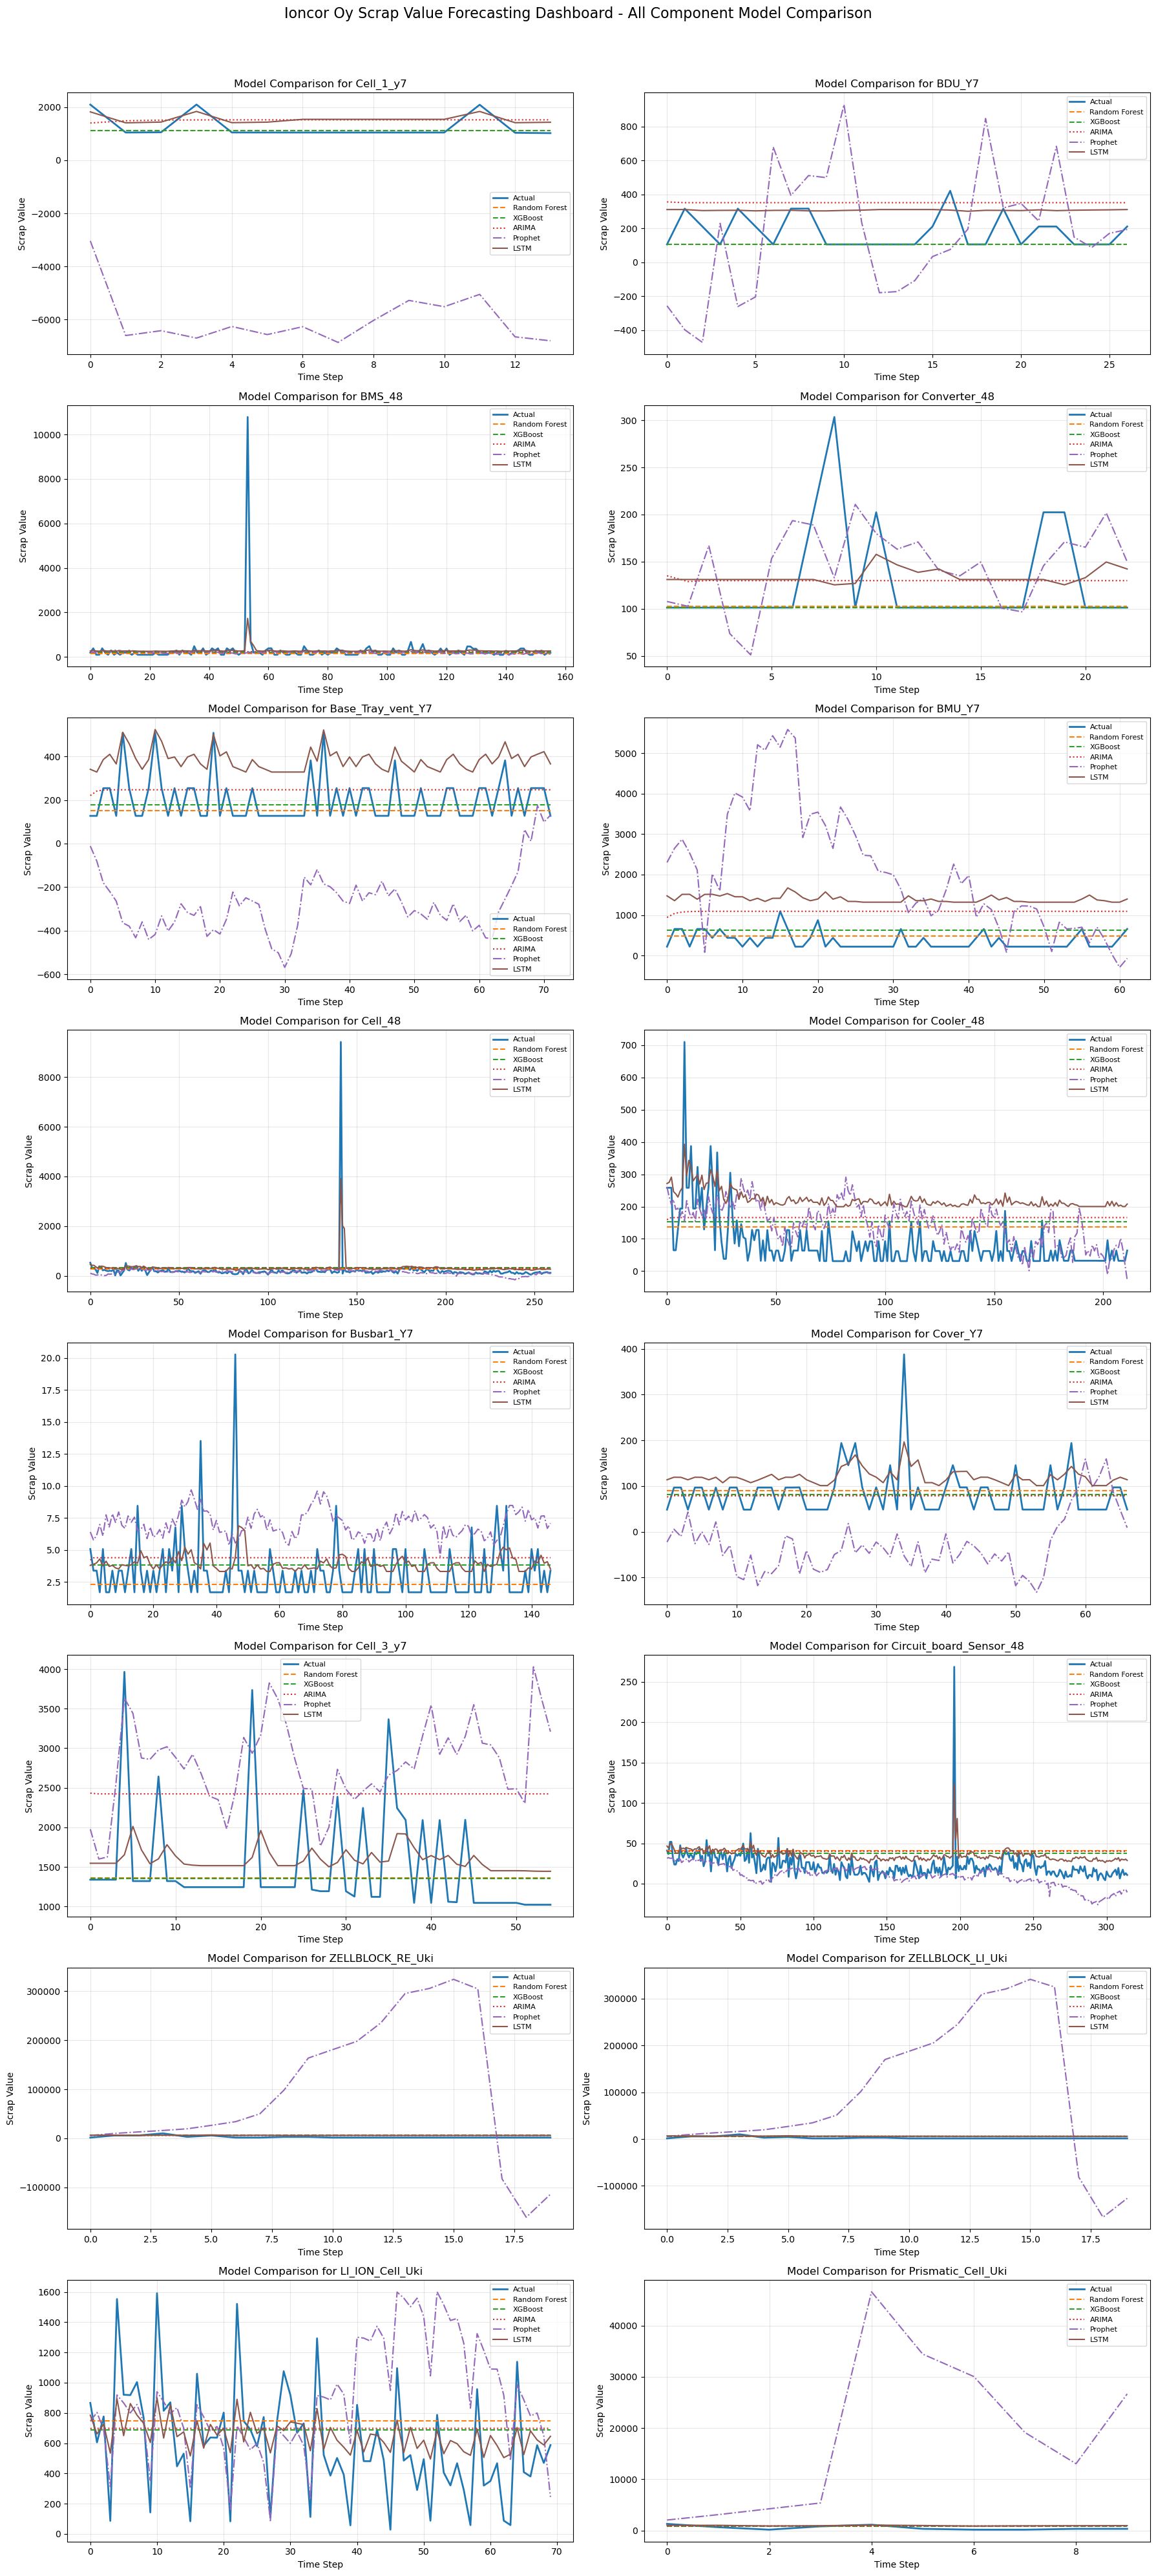

In [74]:
# --- Model Functions ---

def run_rf(df):
    df_rf = df.copy()
    df_rf['Days'] = (df_rf['Posting Date'] - df_rf['Posting Date'].min()).dt.days
    X, y = df_rf[['Days']], df_rf['Unit Price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = RandomForestRegressor(n_estimators=100).fit(X_train, y_train)
    return y_test.values, model.predict(X_test)

def run_xgb(df):
    df_xgb = df.copy()
    df_xgb['Days'] = (df_xgb['Posting Date'] - df_xgb['Posting Date'].min()).dt.days
    X, y = df_xgb[['Days']], df_xgb['Unit Price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model = XGBRegressor().fit(X_train, y_train)
    return y_test.values, model.predict(X_test)

def run_arima(df):
    series = df['Unit Price'].values
    train_size = int(len(series) * 0.8)
    train, test = series[:train_size], series[train_size:]
    model = ARIMA(train, order=(1,1,1)).fit()
    return test, model.forecast(steps=len(test))

def run_prophet(df):
    df_p = df.rename(columns={'Posting Date': 'ds', 'Unit Price': 'y'})
    train_size = int(len(df_p) * 0.8)
    train = df_p.iloc[:train_size]
    test = df_p.iloc[train_size:]
    m = Prophet(yearly_seasonality=True, daily_seasonality=False).fit(train)
    forecast = m.predict(test[['ds']])
    return test['y'].values, forecast['yhat'].values

def run_lstm(df):
    series = df['Unit Price'].values.reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series)
    
    look_back = 3
    X, y = [], []
    for i in range(len(scaled) - look_back):
        X.append(scaled[i:i+look_back, 0])
        y.append(scaled[i+look_back, 0])
    
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], 1, X.shape[1]))
    
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    model = Sequential([LSTM(50, input_shape=(1, look_back)), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=0)
    
    preds = model.predict(X_test)
    return scaler.inverse_transform(y_test.reshape(-1, 1)), scaler.inverse_transform(preds)
    
def _to_1d(arr):
    """Convert pandas/numpy outputs to a clean 1D numpy array."""
    if hasattr(arr, "values"):
        arr = arr.values
    arr = np.asarray(arr).reshape(-1)
    return arr
     # Define the common timeline (2019-2026)
    timeline_start = pd.Timestamp('2019-06-01')
    timeline_end = pd.Timestamp('2026-01-01')
    
    product_list = list(file_dict.items())

def _align_series(*series):
    """Trim all series to the same minimum length."""
    cleaned = [_to_1d(s) for s in series]
    min_len = min(len(s) for s in cleaned if len(s) > 0)
    return [s[:min_len] for s in cleaned]
        
# Layout settings
component_items = list(file_dict.items())
n_components = len(component_items)
ncols = 2
nrows = math.ceil(n_components / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, file_path) in zip(axes, component_items):
    try:
        df_clean = preprocess_time_series(file_path)

        if len(df_clean) < 15:
            ax.set_title(f"{name}\nSkipped: not enough data")
            ax.set_xlabel("Time Step")
            ax.set_ylabel("Scrap Value")
            ax.grid(True, alpha=0.3)
            continue

        # Run all models
        y_test_rf, y_pred_rf = run_rf(df_clean)
        y_test_xgb, y_pred_xgb = run_xgb(df_clean)
        y_test_arima, y_pred_arima = run_arima(df_clean)
        y_test_prophet, y_pred_prophet = run_prophet(df_clean)
        y_test_lstm, y_pred_lstm = run_lstm(df_clean)

        # Use RF test target as the shared "Actual" series,
        # then align all model outputs to the same length.
        actual, pred_rf, pred_xgb, pred_arima, pred_prophet, pred_lstm = _align_series(
            y_test_rf,
            y_pred_rf,
            y_pred_xgb,
            y_pred_arima,
            y_pred_prophet,
            y_pred_lstm
        )

        x = np.arange(len(actual))

        # Plot
        ax.plot(x, actual, label="Actual", linewidth=2)
        ax.plot(x, pred_rf, label="Random Forest", linestyle="--")
        ax.plot(x, pred_xgb, label="XGBoost", linestyle="--")
        ax.plot(x, pred_arima, label="ARIMA", linestyle=":")
        ax.plot(x, pred_prophet, label="Prophet", linestyle="-.")
        ax.plot(x, pred_lstm, label="LSTM", linestyle="-")

        ax.set_title(f"Model Comparison for {name}")
        ax.set_xlabel("Time Step")      # x-axis label
        ax.set_ylabel("Scrap Value")    # y-axis label
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    except Exception as e:
        ax.set_title(f"{name}\nError")
        ax.set_xlabel("Time Step")
        ax.set_ylabel("Scrap Value")
        ax.text(
            0.5, 0.5, str(e),
            ha="center", va="center",
            transform=ax.transAxes,
            wrap=True
        )
        ax.grid(True, alpha=0.3)

# Hide any unused subplot panels
for ax in axes[n_components:]:
    ax.axis("off")

fig.suptitle(
    "Ioncor Oy Scrap Value Forecasting Dashboard - All Component Model Comparison",
    fontsize=16,
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()